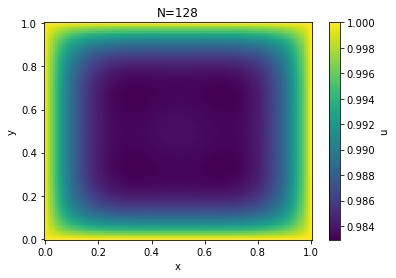

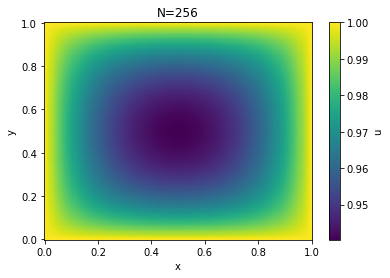

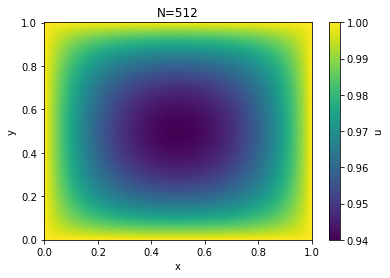

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

u128 = pd.read_csv('ufinal_N128.csv')
u128 = np.array(u128)[:,1:]

u256 = pd.read_csv('ufinal_N256.csv')
u256 = np.array(u256)[:,1:]

u512 = pd.read_csv('ufinal_N512.csv')
u512 = np.array(u512)[:,1:]

x128 = np.linspace(0,1,128); y128=x128
x256 = np.linspace(0,1,256); y256=x256
x512 = np.linspace(0,1,512); y512=x512

plt.figure()
plt.pcolormesh(x128,y128,u128,shading='auto')
plt.colorbar(label='u')
plt.xlabel('x')
plt.ylabel('y')
plt.title('N=128')

plt.figure()
plt.pcolormesh(x256,y256,u256,shading='auto')
plt.colorbar(label='u')
plt.xlabel('x')
plt.ylabel('y')
plt.title('N=256')

plt.figure()
plt.pcolormesh(x512,y512,u512,shading='auto')
plt.colorbar(label='u')
plt.xlabel('x')
plt.ylabel('y')
plt.title('N=512')

plt.show()

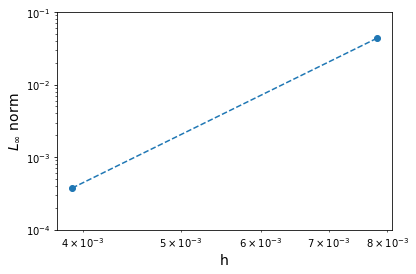

0.04357138799778704
0.0003760866230519966


In [7]:
from scipy.interpolate import griddata

def Linfnorm(uexact, xexact, yexact, uapprox, xapprox, yapprox):
    x_lowN, y_lowN = np.meshgrid(xapprox, yapprox)
    x_highN, y_highN = np.meshgrid(xexact, yexact)
    
    points = np.column_stack([x_highN.ravel(),y_highN.ravel()])
    uexact_lowN = griddata(points, uexact.ravel(), (x_lowN,y_lowN), method='nearest')
    
    return np.max(np.abs(uexact_lowN - uapprox))

err128 = Linfnorm(u512,x512,y512, u128,x128,y128)
err256 = Linfnorm(u512,x512,y512, u256,x256,y256)

plt.figure()
plt.semilogy([1/128,1/256],[err128,err256],'o--')

plt.xlim([1/300,0.009])
plt.ylim([1e-4,1e-1])
plt.xlabel('h',size=14)
plt.ylabel(r'$L_\infty$ norm',size=14)

plt.show()

print(err128)
print(err256)

In [6]:
print(1/128)
print(1/256)

0.0078125
0.00390625
